# 토픽모델링
- 문서 집합의 추상적인 "주제"를 발견하기 위한 통계적 모델 중 하나로, 텍스트 본문의 숨겨진 의미구조를 발견하기 위해 사용되는 텍스트 마이닝 기법
- 대량의 텍스트에서 비슷한 내용을 찾아냄
- 문서 집합에서 주요 주제나 패턴을 자동으로 추출하는 기법

# 판례문 데이터의 토픽모델링 의미

1. 주제별 키워드 패턴 이해
- 특정 법적 용어나 패턴의 반복. 
ex) 형사 : 증거, 피고인, 범죄, 법률 조항 등 / 가사 : 양육권, 재산분할,이혼 등
- 무슨 내용이 중요한지 파악할 수 있다.

2. 주제 간 차이점과 유사점 파악 가능
- 형사, 가사, 개인정보 사건 등의 주제 별 차이점 확인, 유사성 확인(ex: 저작권과 개인정보 관련 사건의 법적 규제나 판례의 논리가 비슷)
- 유사성과 차이점을 파악하여 관련 사건을 파악하는데 도움을 줄 수 있음.

3. 데이터의 효율적인 검색, 탐색 가능
- 비슷한 주제끼리 뭉침
- 특정 주제에 관련한 판례를 더 쉽게 검색하고 탐색할 수 있음

4. 주제 트렌드 분석
- 시간에 따라 특정 법적 사건이나 법률적 이슈가 어떻게 변화하는 지 분석 가능.

5. 기타 법률 연구, 정책 개선에 도움

# 토픽모델링의 평가
- 정성적인 평가
  ( 생성된 토픽의 해석 가능성, 각 토픽 대표 단어의 대표성, 사용자의 주관적 피드백 )
- 시각적인 평가
  ( 각 포인트의 군집을 보고 다른 토픽과 얼마나 겹치지 않는지 )

# bertopic
<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*Jqb4z-hHfQsRXJLS.png" width=600>

# 버전기록
1. 근로자 관련 판례문으로 토픽모델링
   - 너무 주제가 세분화되어있어서 클러스터링의 의미가 없음 (거의 각 문서 별 각 주제)
2. 형사/가사/개인정보/저작권/근로자 판례문에서 랜덤샘플링 100건씩 모아서 토픽모델링
   - 이전 보다는 주제 별 구분이 잘되지만, 법률적 용어의 혼재로 인해 주제와 관련한 의미가 잘 드러나지 않음
3. 주제와 관련없이 중복되는 법률적 용어와 관련한 `stopword` 추가
   - topic representation에서도 개선을 보임. -> LLM 기반의 representation은 더 주제를 잘 대표할까?
4. 모호한 주제 (3개이상의 토픽에서 겹침) -> 주제 수를 줄이면 해결이 될까?
   - bertopic 자체의 `nr_topics`를 활용해서 줄이면 c-tf-idf 계산으로 유사한 주제는 합침
   - hdbscan의 `min_cluster_size`를 늘려서 클러스터의 분포 기반으로도 주제 합침도 가능

In [1]:
import re
from datetime import datetime
import os 
import io
import pandas as pd
import numpy as np
import requests
from sentence_transformers import SentenceTransformer, util
import umap
import plotly.express as px
import hdbscan
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import IFrame

In [2]:
data = pd.read_excel('data.xlsx')

In [3]:
# 분석용 컬럼 생성
data['contents'] = [str(line).strip() for line in data['판례내용']]
data['timestamp'] = [datetime.strptime(line, '%Y-%m-%d').strftime('%Y%m%d') for line in data['선고일자']]

In [4]:
random_state = 1800

In [5]:
legal_stopwords = list(set(["계약", "소송", "법원", "법률", "법적", "조항", "법", "의무", "권리"
                      ,"공소외", "사건", "피고인", "피고가","피고는", "피고에게","피고의","피고인은","피고인의","피고인이", "청구인"
                            ,"청구외", "피청구인", "사건", "정보", "피고", "피고들의","원고들의","원고", "원고인","원고가","원고에게","원고는","원고의","원고와","참가인",
                            "피청구인의","피심판청구인",
                           "같은","있다","상대방","없다","관한","대한","간의","별지","있는","파기하고","대하여","같이",
                            "동의를","등을","동의","기준으로","기준","또는","한다","이를","선고","등의","청구인의","제1항","확인안됨",
                           "사건을","따라","원심은","원심판결","위와","관하여","원심판결을","것으로","상고를","위법이",
                           "의하면", "하여", "의하여", "원심이", "판결", "청구인과",
                           "비추어", "원을", "거기에", "공동피고인", "것이다", "피청구인이",
                           "위하여", "사실을", "원심의", "검사의","처분의", "청구인이","청구인을","청구인은","청구인에게",
                            "사건본인들의","기각한다","내용의","기재","1의",
                           "민법", "가입대상", "소속기관의", "조치를", "피해자의", "대법원", 
                            "상고이유", "가입신청을", "가입의사를", "민법", "피고들은","상고비용은"]))

In [6]:
embedding_model = SentenceTransformer('jhgan/ko-sroberta-multitask')
umap_model = umap.UMAP(random_state=random_state)
hdbscan_model = hdbscan.HDBSCAN(prediction_data=True)
vectorizer_model = CountVectorizer(stop_words=legal_stopwords)
representation_model = MaximalMarginalRelevance(diversity=0.2)
bertopic_model = BERTopic(verbose=True,
                          language='korean',
                          umap_model=umap_model,
                          hdbscan_model=hdbscan_model,
                          embedding_model=embedding_model,
                          vectorizer_model=vectorizer_model,
                          representation_model=representation_model,
                          calculate_probabilities=True)

In [7]:
corpus_embedding = embedding_model.encode(data.contents.tolist(),convert_to_tensor=True)
corpus_embedding = corpus_embedding.cpu()

In [8]:
bertopic_model.fit(data.contents.tolist(), corpus_embedding.numpy())

2025-03-11 13:07:45,739 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-03-11 13:07:49,311 - BERTopic - Dimensionality - Completed ✓
2025-03-11 13:07:49,311 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-11 13:07:49,328 - BERTopic - Cluster - Completed ✓
2025-03-11 13:07:49,329 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-03-11 13:07:55,218 - BERTopic - Representation - Completed ✓


## hdbscan clustering figure, hierarchical clustering, similarity matrix 
주제 간 차이점과 유사점 파악 가능 (가까운 topic끼리 유사, topic 끼리 관계 파악에 유리)
데이터의 효율적인 검색, 탐색 가능

In [9]:
result = pd.DataFrame(bertopic_model.umap_model.embedding_, columns=['x','y'])
result['labels'] = bertopic_model.hdbscan_model.labels_.tolist()
result['title'] = data['topic'].tolist()
result['contents'] = data['contents'].str[20:100]
result['index'] = data.index.values.tolist()
fig = px.scatter(result,
                 x='x', y='y',
                 hover_data=['title', 'index', 'contents'],
                 color='labels')
fig.write_html("figure/fig1.html")

In [10]:
IFrame(src='figure/fig1.html', width=800, height=600)

In [11]:
fig = bertopic_model.visualize_hierarchy()
fig.write_html("figure/fig2.html")

In [32]:
IFrame(src='figure/fig2.html', width=1200, height=600)

In [13]:
fig = bertopic_model.visualize_heatmap()
fig.write_html("figure/fig3.html")

In [31]:
IFrame(src='figure/fig3.html', width=1500, height=1000)

In [15]:
n_topics = len(set(bertopic_model.hdbscan_model.labels_)) - 1
print(n_topics)

20


In [16]:
topics_per_class = bertopic_model.topics_per_class(data.contents.tolist(), data['topic'].tolist())
fig = bertopic_model.visualize_topics_per_class(topics_per_class,top_n_topics=n_topics)
fig.write_html("figure/fig4.html")

5it [00:04,  1.12it/s]


In [28]:
IFrame(src='figure/fig4.html', width=1200, height=900)

## topic over time
주제 트렌드 분석

In [18]:
topics_over_time = bertopic_model.topics_over_time(docs=data.contents,
                      timestamps=data.timestamp,
                      global_tuning=True,
                      evolution_tuning=True)

2025-03-11 13:08:00,322 - BERTopic - WARNING: There are more than 100 unique timestamps (i.e., 450) which significantly slows down the application. Consider setting `nr_bins` to a value lower than 100 to speed up calculation. 
450it [00:46,  9.62it/s]


In [19]:
fig = bertopic_model.visualize_topics_over_time(topics_over_time)
fig.write_html("figure/fig5.html")

In [27]:
IFrame(src='figure/fig5.html', width=1200, height=500)

## wordcloud, topic word score
주제별 키워드 패턴 이해에 도움

In [21]:
fig = bertopic_model.visualize_barchart(top_n_topics=n_topics)
fig.write_html("figure/fig6.html")

In [25]:
IFrame(src='figure/fig6.html', width=1200, height=1200)

Topic 0


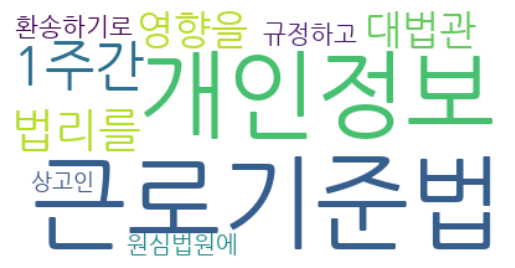

Topic 1


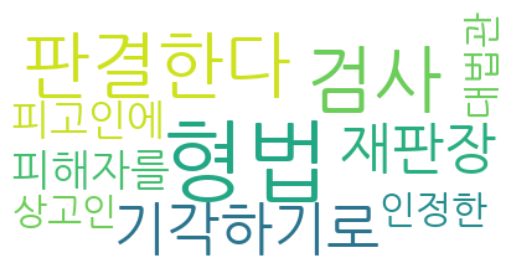

Topic 2


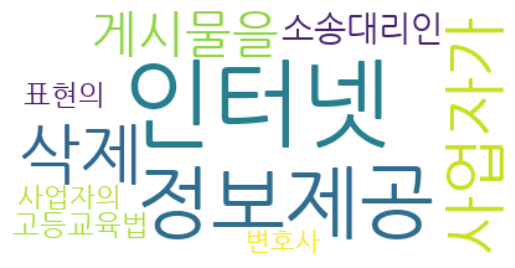

Topic 3


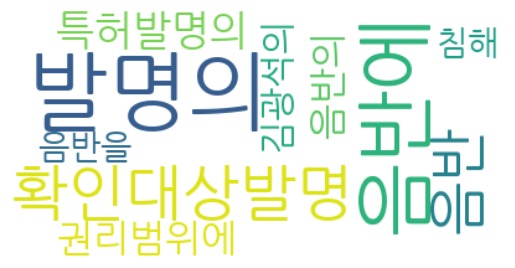

Topic 4


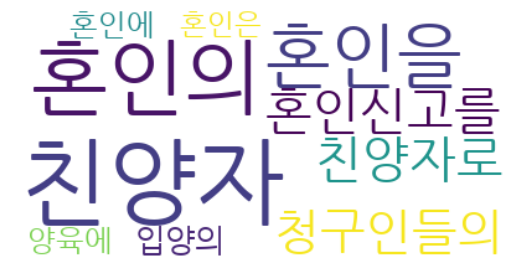

Topic 5


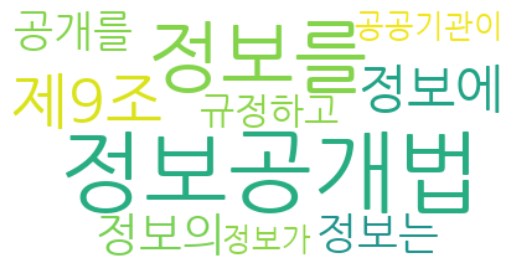

Topic 6


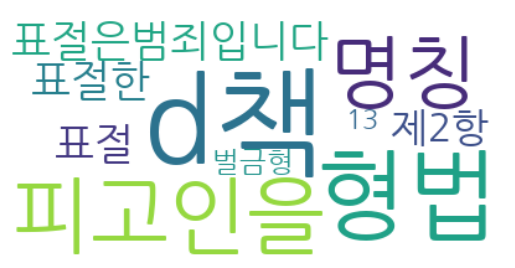

Topic 7


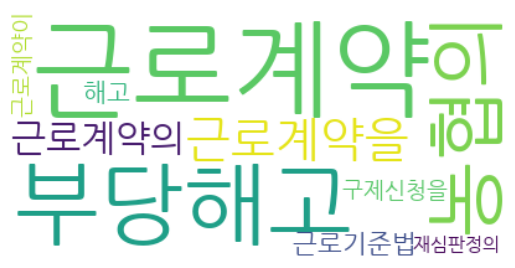

Topic 8


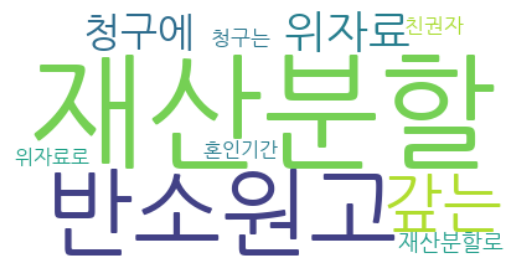

Topic 9


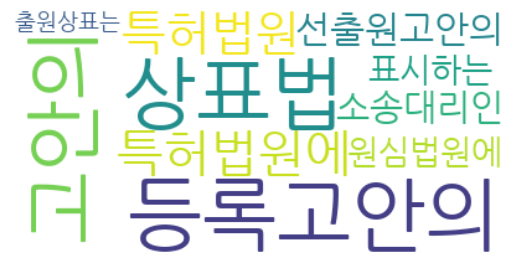

Topic 10


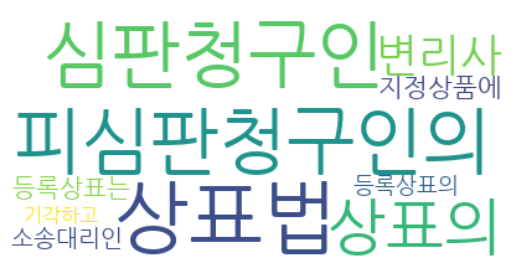

Topic 11


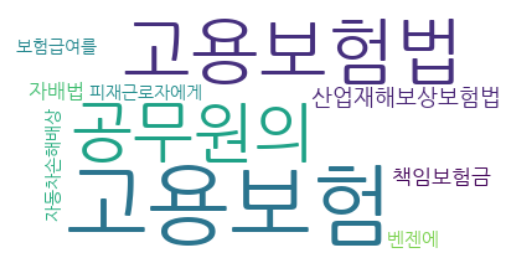

Topic 12


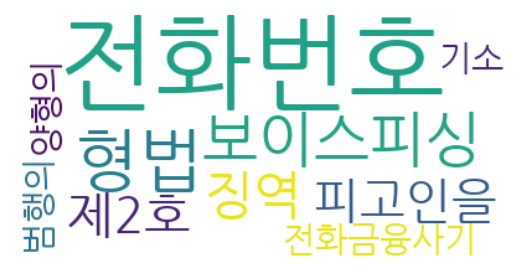

Topic 13


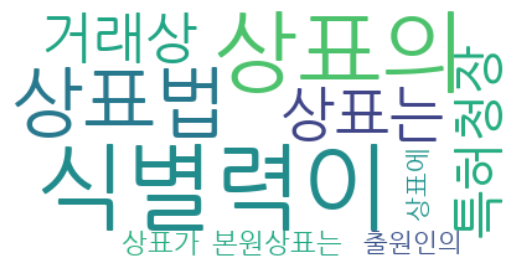

Topic 14


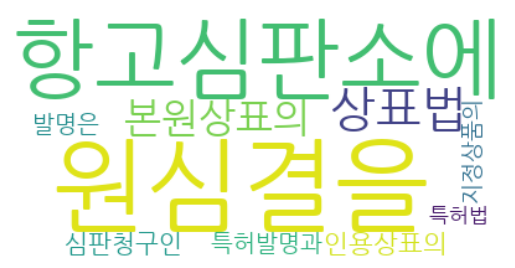

Topic 15


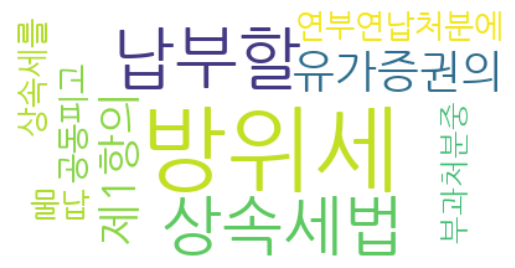

Topic 16


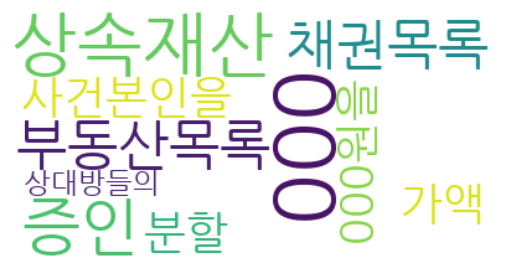

Topic 17


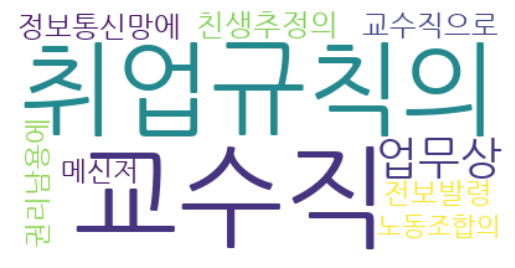

Topic 18


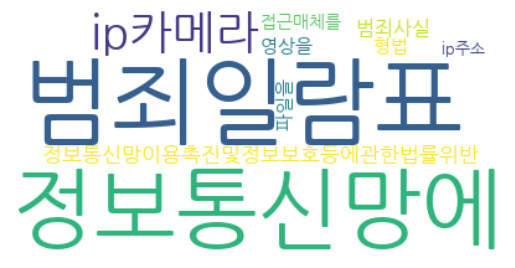

Topic 19


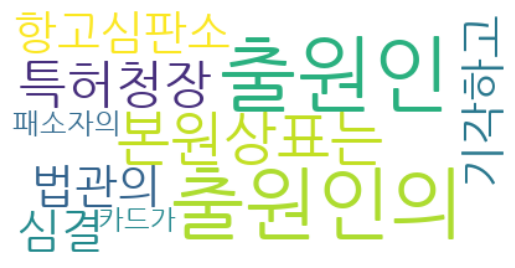

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    font_path = '/Library/Fonts/NanumGothic.ttf'
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(font_path=font_path, background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
for i in range(0,n_topics):
    print(f"Topic {i}")
    create_wordcloud(bertopic_model, topic=i)


# 개선점
1. Topic representation을 LLM 기반으로
   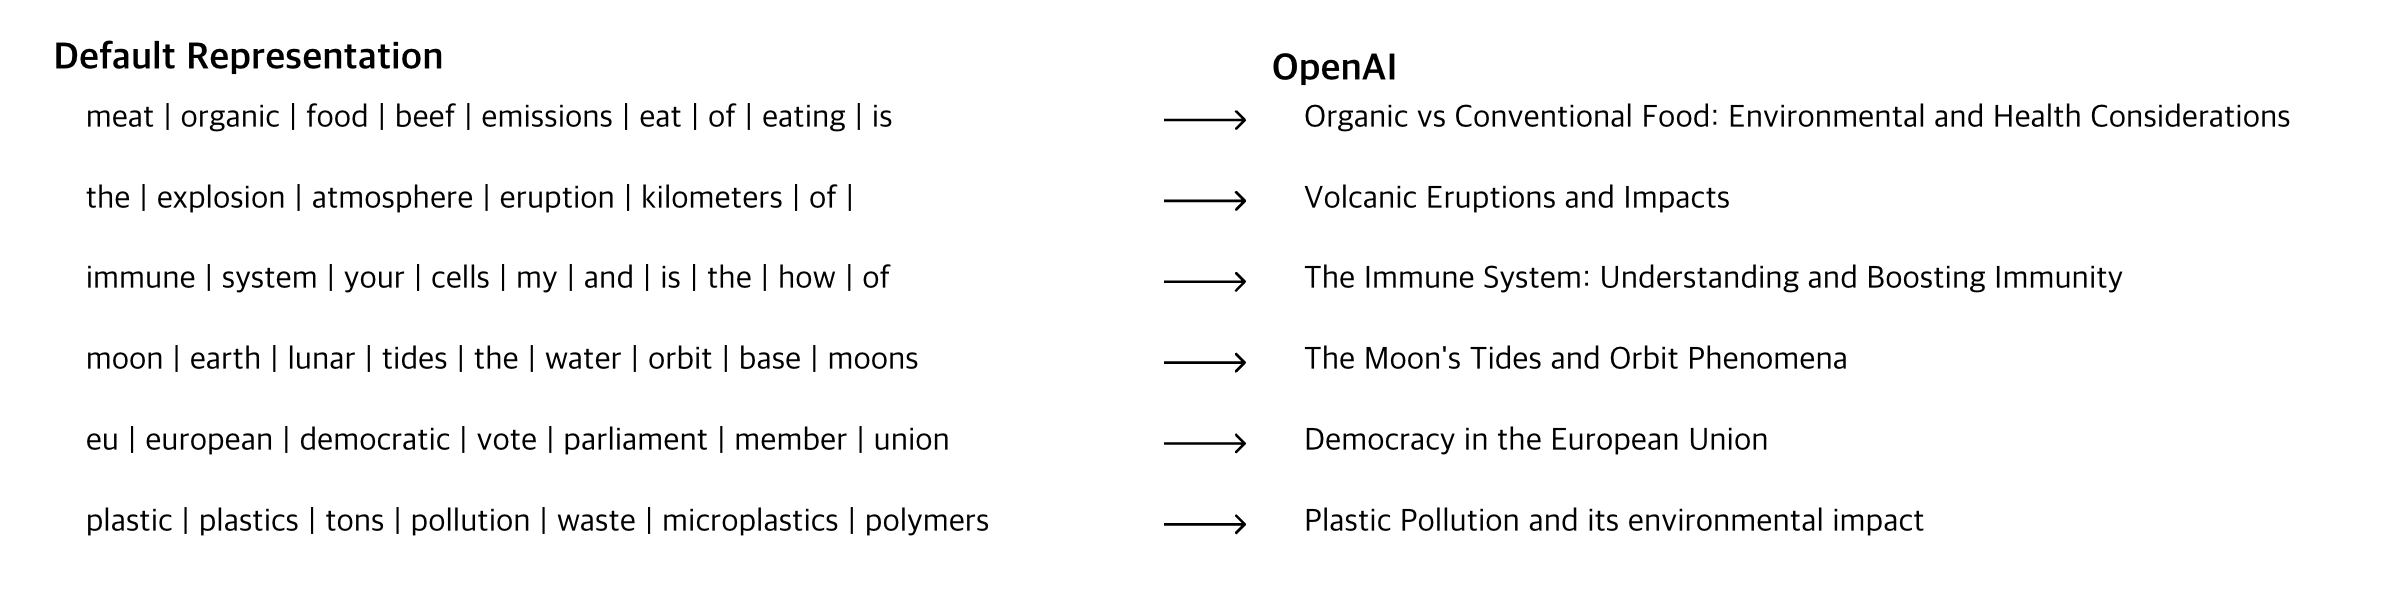
2. 텍스트 전처리
3. 법률 도메인에 특화된 임베딩 모델